## Limpieza de datos: pobreza_poblacion_ocupada_formalidad.csv obtenido de Cuadro_de_indicadores_ITLP_4T2024.xlsx

In [1]:
import pandas as pd
import numpy as np

ruta_cruda = '../data/pobreza_poblacion_ocupada_formalidad.csv'
columnas_utiles = [2, 3, 5, 6, 7, 9, 10, 11]
nombres_limpios = [
    'anio', 'trimestre', 
    'pobreza_total', 'pobreza_formal', 'pobreza_informal', 
    'ingreso_total', 'ingreso_formal', 'ingreso_informal'
]

In [2]:
#Cargar el CSV ignorando renglones inservibles
df_form = pd.read_csv(ruta_cruda, skiprows=7, usecols=columnas_utiles, names=nombres_limpios)

In [3]:
#Limpieza de la estructura
df_form['anio'] = df_form['anio'].ffill()
df_form = df_form.dropna(subset=["trimestre"])
df_form['trimestre'] = df_form['trimestre'].replace({'ll*': 'II', 'IV**': 'IV'})
df_form = df_form.replace({'ND': np.nan, ' ND ': np.nan})

In [4]:
#Limpieza de caracteres que no sirven y conversiones a numéricos
columnas_metricas = [
    'pobreza_total', 'pobreza_formal', 'pobreza_informal', 
    'ingreso_total', 'ingreso_formal', 'ingreso_informal'
]

for col in columnas_metricas:
    df_form[col] = df_form[col].astype(str).str.replace('$', '', regex=False)\
                                           .str.replace(',', '', regex=False)\
                                           .str.strip()
    df_form[col] = pd.to_numeric(df_form[col].replace('nan', np.nan), errors='coerce')

In [5]:
#Estandarización del tipo de dato de año
df_form['anio']= df_form['anio'].astype(float).astype('Int64')

In [6]:
# Display de las primeras filas del df limpio
df_form.head(10)

,anio,trimestre,pobreza_total,pobreza_formal,pobreza_informal,ingreso_total,ingreso_formal,ingreso_informal
0,2005,I,16.5,0.8,26.8,6677.89,10360.99,4246.08
1,2005,II,17.1,0.9,27.7,6651.84,10347.07,4234.24
2,2005,III,17.6,0.9,28.3,6618.29,10479.46,4151.38
3,2005,IV,16.1,0.7,26.1,6813.61,10674.35,4319.45
4,2006,I,15.6,0.7,25.6,6851.87,10610.62,4331.74
5,2006,II,15.7,0.6,25.5,6919.19,10697.64,4446.31
6,2006,III,16.4,0.7,27.0,6972.37,10845.47,4341.55
7,2006,IV,16.1,0.7,26.6,6832.15,10514.75,4295.17
8,2007,I,15.5,0.6,25.9,6920.56,10656.11,4321.20
9,2007,II,15.6,0.7,25.7,7018.15,10767.80,4443.21


In [7]:
#Ultima verificacion
print(df_form.info())

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   anio              80 non-null     Int64  
 1   trimestre         80 non-null     object 
 2   pobreza_total     79 non-null     float64
 3   pobreza_formal    79 non-null     float64
 4   pobreza_informal  79 non-null     float64
 5   ingreso_total     79 non-null     float64
 6   ingreso_formal    79 non-null     float64
 7   ingreso_informal  79 non-null     float64
dtypes: Int64(1), float64(6), object(1)
memory usage: 5.7+ KB
None


In [8]:
#Exportamos el archivo
df_form.to_csv('../data/clean_data/pobreza_poblacion_ocupada_formalidad_clean.csv',)

## Visualizacion exploratoria

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

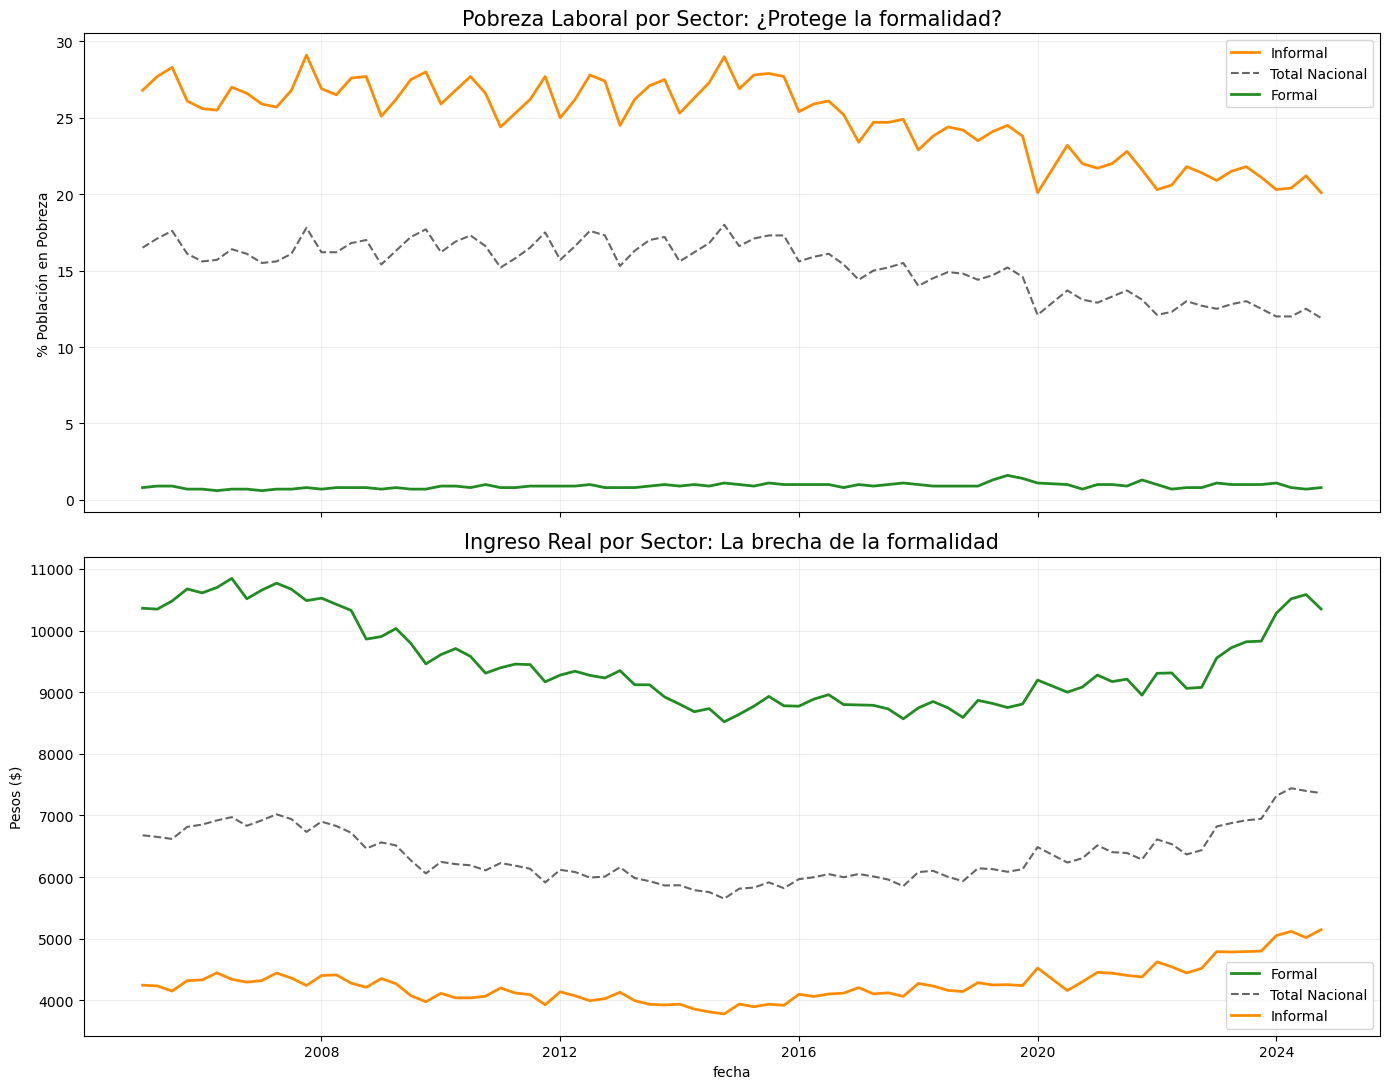

In [10]:
mapping = {'I': '01-01', 'II': '04-01', 'III': '07-01', 'IV': '10-01'}
df_form['fecha'] = pd.to_datetime(df_form['anio'].astype(int).astype(str) + '-' + df_form['trimestre'].map(mapping))

# Configuramos la figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

# --- Pobreza por Sector ---
sns.lineplot(data=df_form, x='fecha', y='pobreza_informal', ax=ax1, color='darkorange', label='Informal', linewidth=2)
sns.lineplot(data=df_form, x='fecha', y='pobreza_total', ax=ax1, color='black', label='Total Nacional', linestyle='--', alpha=0.6)
sns.lineplot(data=df_form, x='fecha', y='pobreza_formal', ax=ax1, color='forestgreen', label='Formal', linewidth=2)

ax1.set_title('Pobreza Laboral por Sector: ¿Protege la formalidad?', fontsize=15)
ax1.set_ylabel('% Población en Pobreza')
ax1.grid(True, alpha=0.2)

# --- Ingresos por Sector ---
sns.lineplot(data=df_form, x='fecha', y='ingreso_formal', ax=ax2, color='forestgreen', label='Formal', linewidth=2)
sns.lineplot(data=df_form, x='fecha', y='ingreso_total', ax=ax2, color='black', label='Total Nacional', linestyle='--', alpha=0.6)
sns.lineplot(data=df_form, x='fecha', y='ingreso_informal', ax=ax2, color='darkorange', label='Informal', linewidth=2)

ax2.set_title('Ingreso Real por Sector: La brecha de la formalidad', fontsize=15)
ax2.set_ylabel('Pesos ($)')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

La siguiente grafica analiza la dinamica de la desigualdad. Calcularemos el indice de Proporcion de Ingresos Formal/ Informal. Es decir, Responde la pregunta " Por cada peso que gana una persona en el sector informal, cuantos gana una persona en el sector formal?"

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

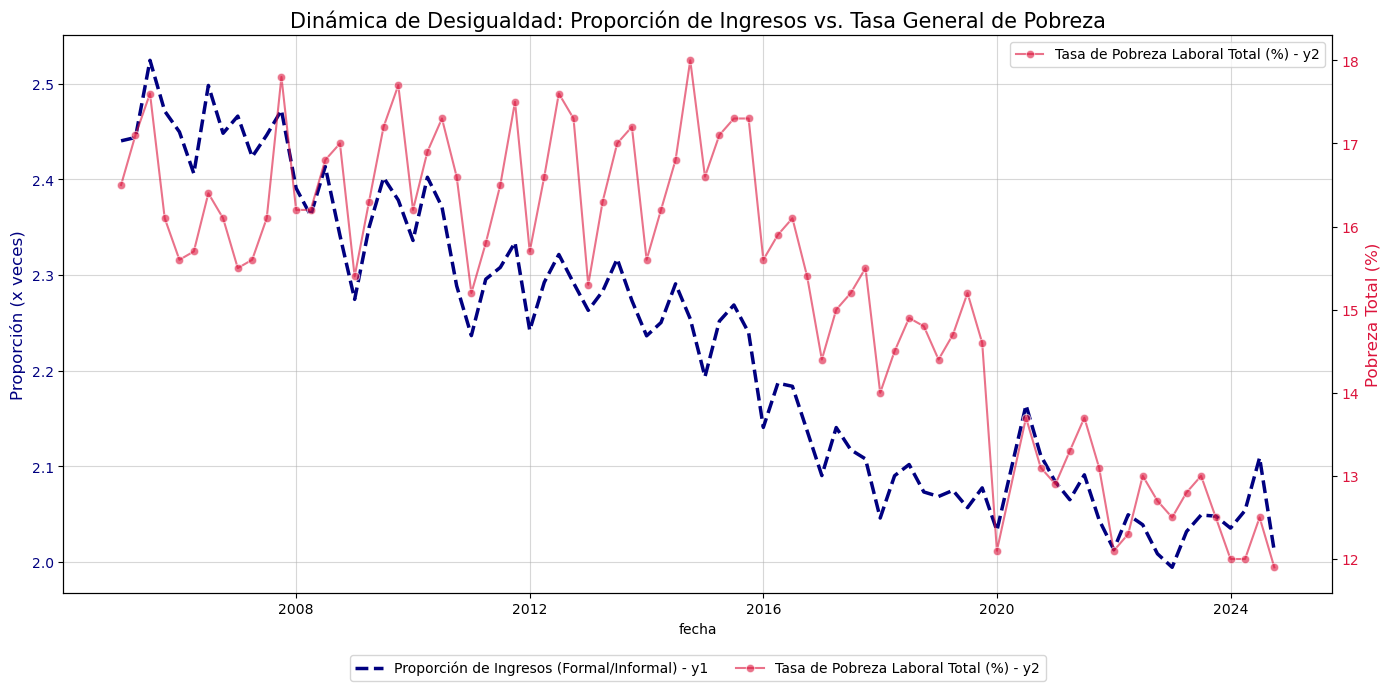

In [12]:

mapping = {'I': '01-01', 'II': '04-01', 'III': '07-01', 'IV': '10-01'}
df_form['fecha'] = pd.to_datetime(df_form['anio'].astype(int).astype(str) + '-' + df_form['trimestre'].map(mapping))

# Cálculo de la métrica de desigualdad
# Proporción de ingresos Formal vs Informal (Formal / Informal)
df_form['ratio_ingreso_FI'] = df_form['ingreso_formal'] / df_form['ingreso_informal']

# --- CREACIÓN DE LA GRÁFICA DE DOBLE EJE ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Gráfica del Eje 1 (Izquierdo): Proporción de Ingresos
sns.lineplot(data=df_form, x='fecha', y='ratio_ingreso_FI', color='navy', linestyle='--', linewidth=2.5, 
             label='Proporción de Ingresos (Formal/Informal) - y1', ax=ax1)

ax1.set_title('Dinámica de Desigualdad: Proporción de Ingresos vs. Tasa General de Pobreza', fontsize=15)
ax1.set_ylabel('Proporción (x veces)', color='navy', fontsize=12)
ax1.tick_params(axis='y', labelcolor='navy')
ax1.grid(True, alpha=0.5)

# Crear el segundo eje Y (Derecho)
ax2 = ax1.twinx()

# Gráfica del Eje 2 (Derecho): Pobreza Total
sns.lineplot(data=df_form, x='fecha', y='pobreza_total', color='crimson', marker='o', alpha=0.6,
             label='Tasa de Pobreza Laboral Total (%) - y2', ax=ax2)

ax2.set_ylabel('Pobreza Total (%)', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

# Unificando las leyendas de ambos ejes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.tight_layout()
plt.show()

Que nos dice esta grafica? 
La linea azul es el radio, podemos observar que a traves del tiempo ha tomado valores de entre 2.0 y 2.6, es decir, un trabajador formal gana en promedio mas de dos veces lo que gana un informal por su trabajo, lo que significa una brecha enorme. Por que esto importa? Al observar los movimientos de ambas lineas, podemos notar que cuando la linea azul (que representa la desigualdad por sector) tiene picos, tambien los tiene la linea roja, lo cual indica que existe una fuerte correlacion entre la desigualdad de ingresos entre sectores y la pobreza nacional.